In [12]:
## Exploratory Data Analysis (EDA) ##

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import folium
from math import radians, sin, cos, sqrt, atan2
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Load data
df = pd.read_csv("/home/amolla/GIS_Spring26/GIS_521_FinalProject/BRAZIL_AllVariables_Combined_with_LatLon.csv")

static_vars = [
    "near_coast_km", "elevation_meter",
    "population_density", "builtup_density",
    "latitude", "longitude"
]

monthly_var_bases = [
    "pdsi",
    "skin_temperature",
    "temperature_2m_max", "temperature_2m_min",
    "total_precipitation_sum", "vs"
]

dengue_base = "den"

months = [f"{m:02d}" for m in range(1, 13)]
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# ── 1. Static variables ───────────────────────────────────────────────────────
static_rows = []
for v in static_vars:
    s = df[v].dropna()
    static_rows.append({
        'Variable': v,
        'Type': 'Static',
        'Stat': 'Mean',
        'Overall (Static)': s.mean(),
        'Std': s.std(),
        'Min': s.min(),
        'Max': s.max(),
        **{label: np.nan for label in month_labels}
    })
    static_rows.append({
        'Variable': v,
        'Type': 'Static',
        'Stat': 'Std',
        'Overall (Static)': s.std(),
        'Std': np.nan,
        'Min': np.nan,
        'Max': np.nan,
        **{label: np.nan for label in month_labels}
    })
    static_rows.append({
        'Variable': v,
        'Type': 'Static',
        'Stat': 'Min',
        'Overall (Static)': s.min(),
        'Std': np.nan,
        'Min': np.nan,
        'Max': np.nan,
        **{label: np.nan for label in month_labels}
    })
    static_rows.append({
        'Variable': v,
        'Type': 'Static',
        'Stat': 'Max',
        'Overall (Static)': s.max(),
        'Std': np.nan,
        'Min': np.nan,
        'Max': np.nan,
        **{label: np.nan for label in month_labels}
    })

# ── 2. Monthly variables ──────────────────────────────────────────────────────
all_bases = monthly_var_bases + [dengue_base]

monthly_rows = []
for base in all_bases:
    var_type = 'Dengue (Monthly)' if base == dengue_base else 'Monthly'
    for stat in ['Mean', 'Std', 'Min', 'Max']:
        row = {
            'Variable': base,
            'Type': var_type,
            'Stat': stat,
            'Overall (Static)': np.nan,  # not applicable for monthly
            'Std': np.nan,
            'Min': np.nan,
            'Max': np.nan,
        }
        for m, label in zip(months, month_labels):
            col = f"{base}_2019_{m}"
            if col not in df.columns:
                print(f"WARNING: {col} not found, skipping.")
                row[label] = np.nan
            else:
                s = df[col].dropna()
                if stat == 'Mean':
                    row[label] = s.mean()
                elif stat == 'Std':
                    row[label] = s.std()
                elif stat == 'Min':
                    row[label] = s.min()
                elif stat == 'Max':
                    row[label] = s.max()
        monthly_rows.append(row)

# ── 3. Combine and save ───────────────────────────────────────────────────────
final_df = pd.DataFrame(static_rows + monthly_rows)

# Reorder columns cleanly
col_order = ['Variable', 'Type', 'Stat', 'Overall (Static)'] + month_labels
final_df = final_df[col_order]

output_path = "/home/amolla/GIS_Spring26/GIS_521_FinalProject/summary_table.csv"
final_df.to_csv(output_path, index=False)

# ── 4. Print ──────────────────────────────────────────────────────────────────
pd.set_option('display.float_format', '{:,.3f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
print(final_df.to_string(index=False))
print(f"\nSaved: {output_path}")


               Variable             Type Stat  Overall (Static)       Jan       Feb        Mar        Apr        May        Jun       Jul       Aug       Sep       Oct       Nov       Dec
          near_coast_km           Static Mean           360.631       NaN       NaN        NaN        NaN        NaN        NaN       NaN       NaN       NaN       NaN       NaN       NaN
          near_coast_km           Static  Std           319.272       NaN       NaN        NaN        NaN        NaN        NaN       NaN       NaN       NaN       NaN       NaN       NaN
          near_coast_km           Static  Min             0.078       NaN       NaN        NaN        NaN        NaN        NaN       NaN       NaN       NaN       NaN       NaN       NaN
          near_coast_km           Static  Max         1,621.588       NaN       NaN        NaN        NaN        NaN        NaN       NaN       NaN       NaN       NaN       NaN       NaN
        elevation_meter           Static Mean           452.

In [3]:
## Data Transformation for Modeling 

# 1. Load wide CSV

wide_csv = "/home/amolla/GIS_Spring26/GIS_521_FinalProject/BRAZIL_AllVariables_Combined_with_LatLon.csv"
df_wide = pd.read_csv(wide_csv)

# Strip hidden spaces
df_wide.columns = df_wide.columns.str.strip()

assert "Common_ID" in df_wide.columns, "❌ Common_ID column missing"


# Configuration


id_cols = [
    "Common_ID", "imputed_deng", "gaul0_name", "gaul1_code",
    "gaul1_name", "gaul2_code", "gaul2_name", "ADM2_KEY"
]

static_vars = [
    "near_coast_km", "elevation_meter", "slope",
    "built_surface_2020", "gdp_2018", "population_2019",
    "latitude", "longitude"
]

monthly_vars = [
    "dengue", "pdsi",
    "skin_temperature", "surface_pressure",
    "temperature_2m", "temperature_2m_max",
    "temperature_2m_min", "total_precipitation_sum", "vs"
]


# Index by Common_ID

wide_lookup = df_wide.set_index("Common_ID").to_dict(orient="index")


# Build panel dataset

panel_rows = []

for common_id, wide_row in wide_lookup.items():

    for m in range(1, 13):

        panel_row = {}

        # ---- Common_ID comes from the key
        panel_row["Common_ID"] = common_id

        # ---- Other ID columns
        for col in id_cols:
            if col != "Common_ID":
                panel_row[col] = wide_row[col]

        # ---- Static predictors
        for col in static_vars:
            panel_row[col] = wide_row[col]

        # ---- Dependent variable
        panel_row["dengue"] = wide_row[f"den_2019_{m:02d}"]
        panel_row["date"] = f"2019-{m:02d}-01"

        # ---- Monthly predictors with TRUE temporal lags
        for var in monthly_vars:
            for lag in range(1,3):
                month_idx = m - lag
                year = 2019

                if month_idx <= 0:
                    month_idx += 12
                    year = 2018

                wide_col = f"{var}_{year}_{month_idx:02d}"
                panel_col = f"{var}_lagvalue_lag{lag}"

                panel_row[panel_col] = (
                    wide_row[wide_col] if wide_col in wide_row else np.nan
                )

        panel_rows.append(panel_row)


# Save output

df_panel = pd.DataFrame(panel_rows)

out_csv = (
    "/home/amolla/GIS_Spring26/GIS_521_FinalProject/"
    "brazil_panel_2019_lagged_raw.csv"
)

df_panel.to_csv(out_csv, index=False)

print("✅ Panel creation successful")
print(f"📐 Shape: {df_panel.shape}")
print(f"📁 Saved to: {out_csv}")


✅ Panel creation successful
📐 Shape: (66816, 62)
📁 Saved to: /home/amolla/GIS_Spring26/GIS_521_FinalProject/brazil_panel_2019_lagged_raw.csv


In [4]:
## Sanity-Check for Data Transformation

# Load data

wide_csv = "/home/amolla/GIS_Spring26/GIS_521_FinalProject/BRAZIL_AllVariables_Combined_with_LatLon.csv"
panel_csv = "/home/amolla/GIS_Spring26/GIS_521_FinalProject/brazil_panel_2019_lagged_raw.csv"

df_wide = pd.read_csv(wide_csv)
df_panel = pd.read_csv(panel_csv)

# Clean column names
df_wide.columns = df_wide.columns.str.strip()
df_panel.columns = df_panel.columns.str.strip()


# Configuration

var = "temperature_2m"
lags = 4


# Index wide data

df_wide = df_wide.set_index("Common_ID")


# Validate

mismatches = []

for _, prow in df_panel.iterrows():

    cid = prow["Common_ID"]
    year, month, _ = prow["date"].split("-")
    month = int(month)

    wide_row = df_wide.loc[cid]

    # ---- Expected values from wide CSV
    expected = []
    for lag in range(lags):
        m_idx = month - lag
        y = 2019
        if m_idx <= 0:
            m_idx += 12
            y = 2018

        col = f"{var}_{y}_{m_idx:02d}"
        expected.append(wide_row[col] if col in wide_row else np.nan)

    expected = np.asarray(expected, dtype=float)

    # ---- Observed lag values from panel CSV
    lag_cols = [f"{var}_lagvalue_lag{i}" for i in range(lags)]
    observed = np.asarray(
        [prow[c] for c in lag_cols],
        dtype=float
    )

    # ---- Compare
    if not np.allclose(expected, observed, equal_nan=True):
        mismatches.append((cid, month, expected, observed))


# Report

if not mismatches:
    print(f"✅ PERFECT MATCH — {var} lag construction is correct")
else:
    print(f"❌ Found {len(mismatches)} mismatches\n")
    for cid, m, exp, obs in mismatches[:10]:
        print(f"Common_ID: {cid}, Month: {m:02d}")
        print("Wide CSV :", exp)
        print("Panel CSV:", obs)
        print("-" * 50)


✅ PERFECT MATCH — temperature_2m lag construction is correct


Data shape: (55680, 69)

=== April 2019 Forecast (Log-Transform) ===
RMSE: 587.663, MAE: 48.064, R²: 0.229


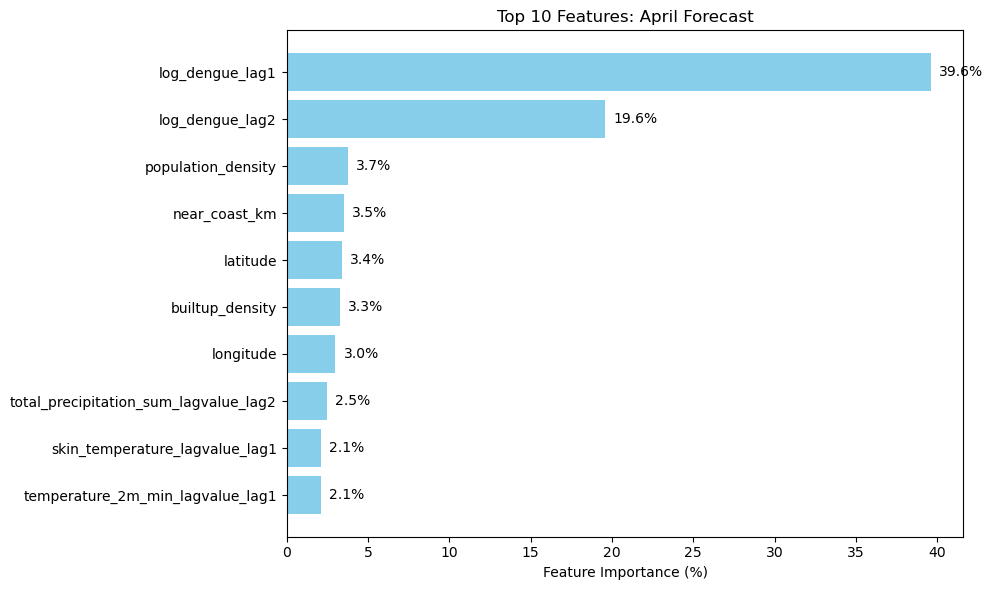


=== May 2019 Forecast (Log-Transform) ===
RMSE: 637.148, MAE: 45.331, R²: 0.362


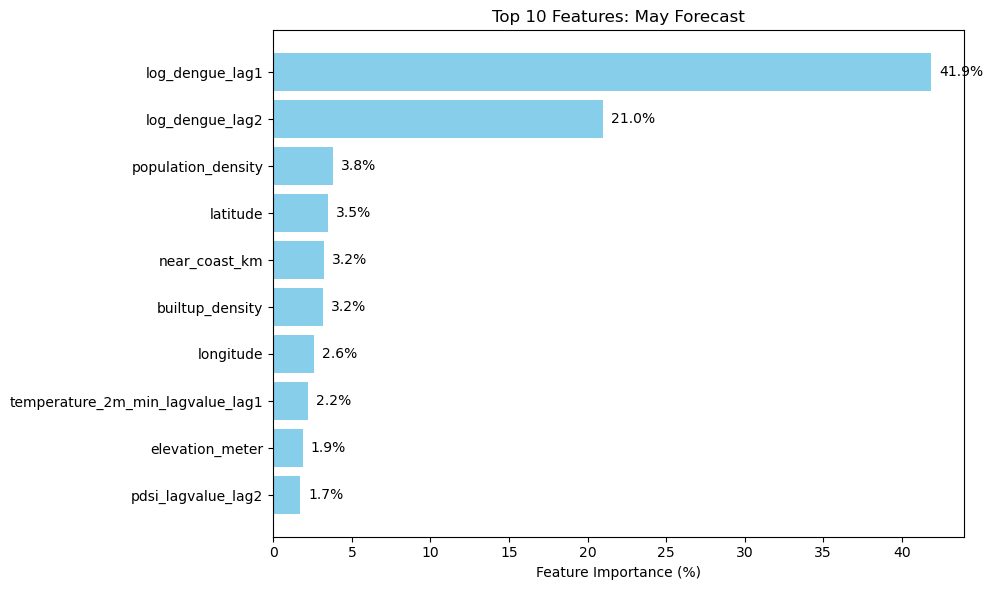


=== June 2019 Forecast (Log-Transform) ===
RMSE: 227.401, MAE: 27.589, R²: 0.673


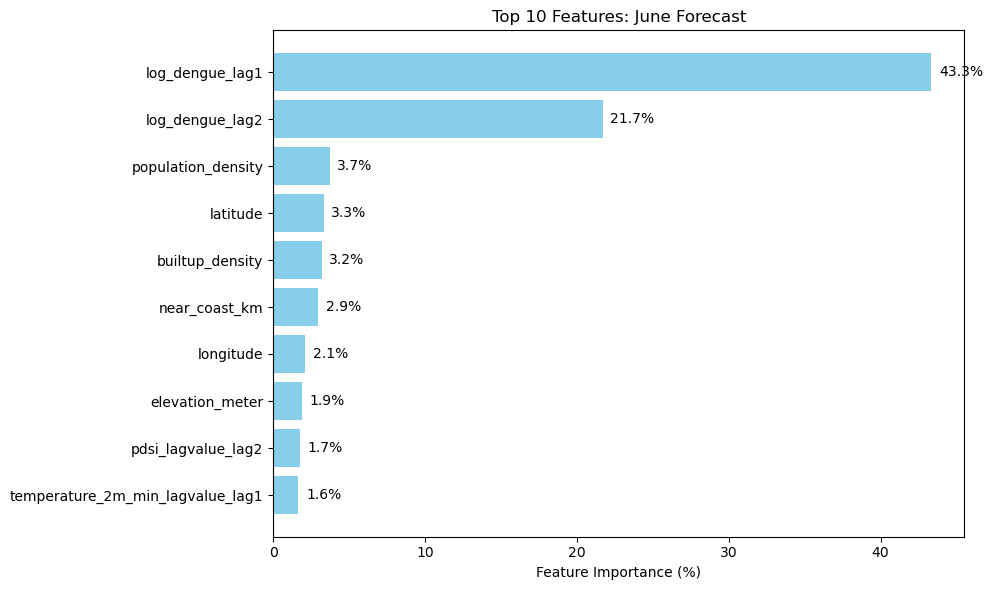


=== July 2019 Forecast (Log-Transform) ===
RMSE: 48.624, MAE: 11.345, R²: 0.617


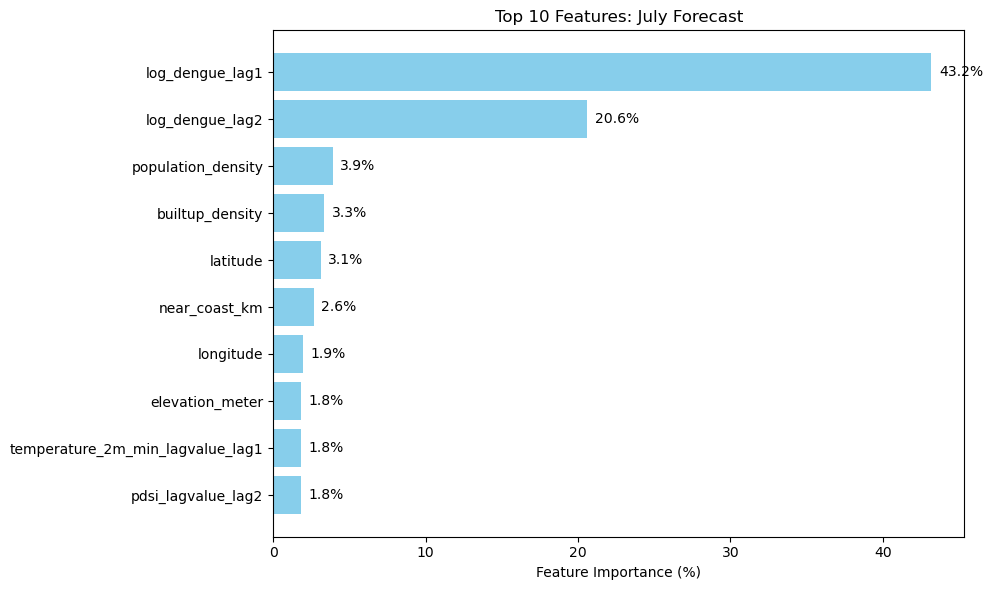


=== August 2019 Forecast (Log-Transform) ===
RMSE: 19.501, MAE: 3.793, R²: 0.881


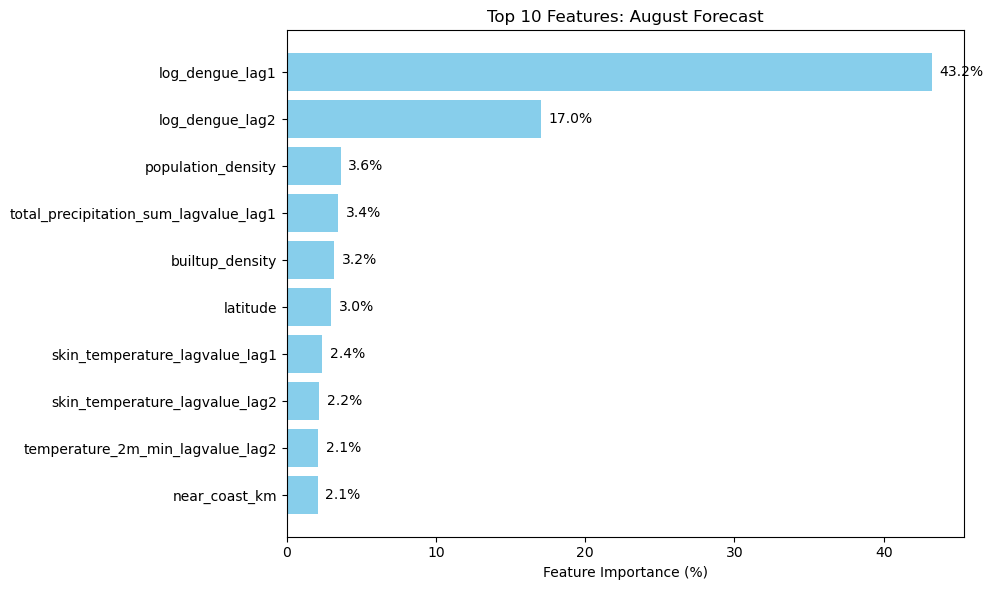


=== September 2019 Forecast (Log-Transform) ===
RMSE: 17.760, MAE: 2.557, R²: 0.714


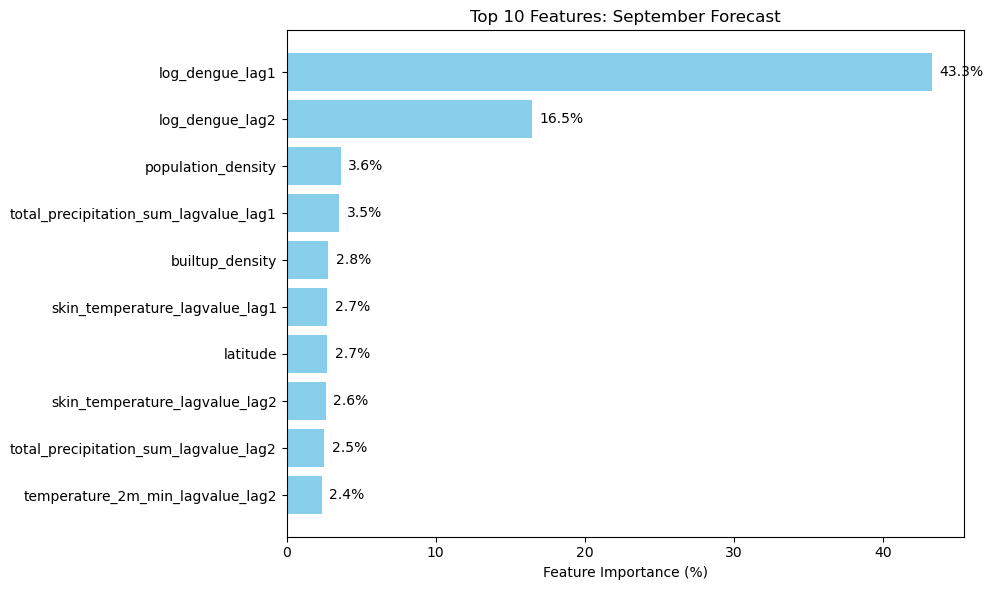


=== October 2019 Forecast (Log-Transform) ===
RMSE: 13.258, MAE: 2.564, R²: 0.804


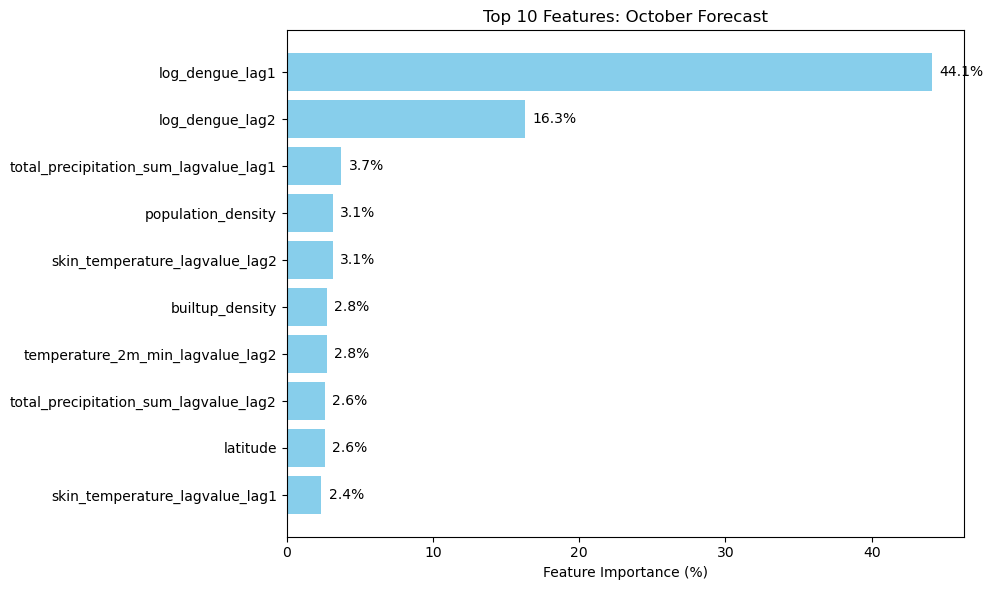


=== November 2019 Forecast (Log-Transform) ===
RMSE: 35.709, MAE: 4.859, R²: 0.503


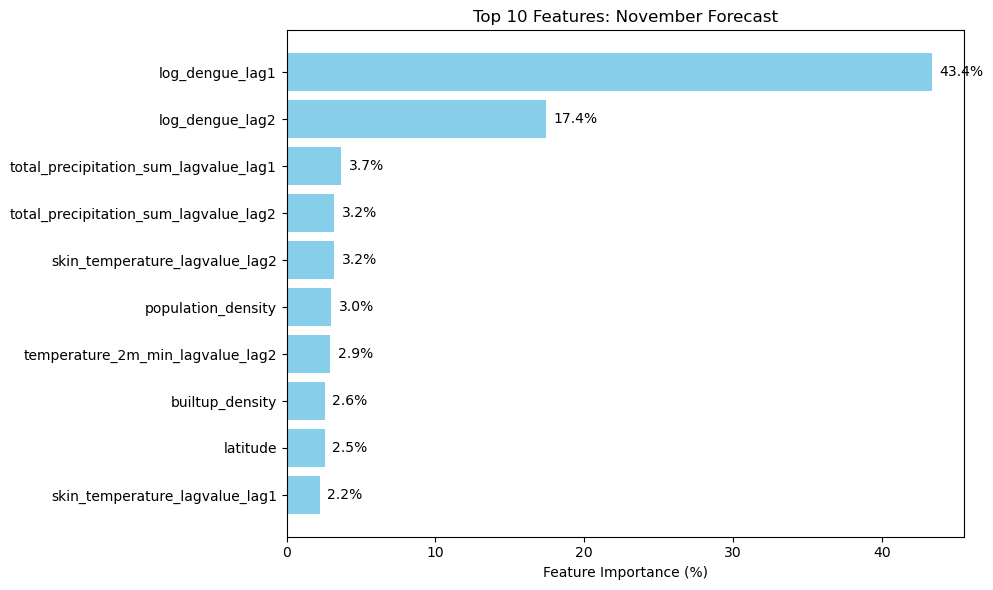


=== December 2019 Forecast (Log-Transform) ===
RMSE: 30.886, MAE: 4.951, R²: 0.619


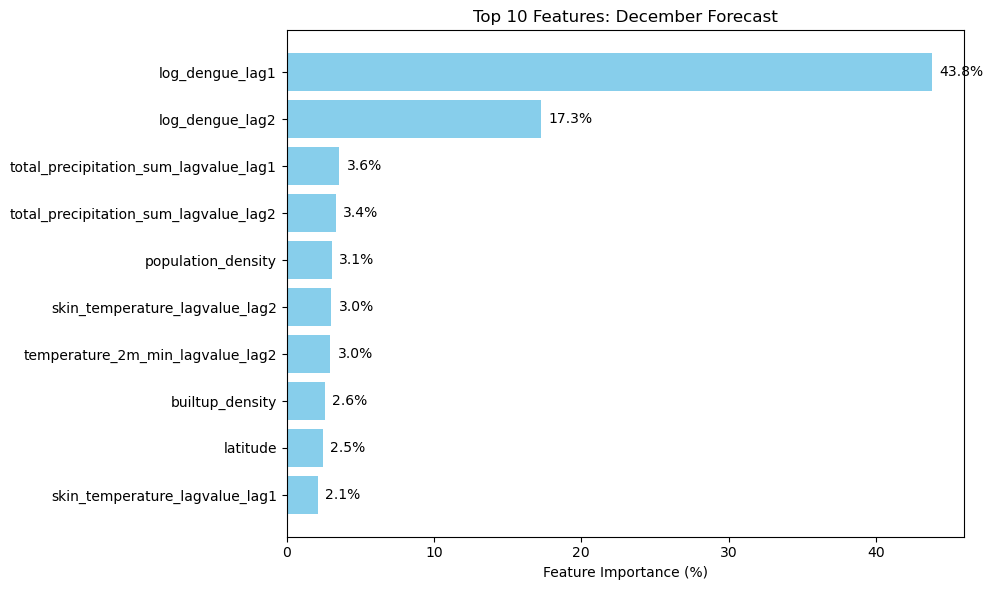


=== Combined April–December 2019 Forecast ===
RMSE: 299.719
MAE : 16.784
R²  : 0.362


In [3]:

# Random Forest Expanding Window Forecast (April–December 2019)

# Load Dataset

panel_csv = "/home/amolla/GIS_Spring26/GIS_521_FinalProject/brazil_panel_2019_FINAL.csv"
df = pd.read_csv(panel_csv)
df.columns = df.columns.str.strip()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["Common_ID", "date"])

print("Data shape:", df.shape)

# ===============================
# Apply log1p transform
# ===============================
df["log_dengue"] = np.log1p(df["dengue"])
df["log_dengue_lag1"] = np.log1p(df["dengue_lagvalue_lag1"])
df["log_dengue_lag2"] = np.log1p(df["dengue_lagvalue_lag2"])


# Configuration

target = "log_dengue"

# Static features
static_vars = [
    "near_coast_km", "elevation_meter",
    "population_density", "builtup_density",
    "latitude", "longitude"
]

# Monthly climate variables
monthly_vars = [
    "pdsi",
    "skin_temperature",
    "temperature_2m_max", "temperature_2m_min",
    "total_precipitation_sum", "vs"
]

# Lagged climate variables (1- and 2-month lags)
climate_lags = [
    f"{var}_lagvalue_lag{lag}"
    for var in monthly_vars
    for lag in range(1,3)
]

# Full feature set
features = static_vars + climate_lags + [
    "log_dengue_lag1",
    "log_dengue_lag2"
]

# Random Forest parameters
rf_params = {
    'n_estimators': 1000,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'sqrt',
    'n_jobs': -1,
    'random_state': 42
}


# Helper function

def rf_forecast(train_df, test_df, features, target, month_name):
    X_train = train_df[features].values
    y_train = train_df[target].values
    X_test = test_df[features].values
    y_test = test_df[target].values

    # Train Random Forest
    rf = RandomForestRegressor(**rf_params)
    rf.fit(X_train, y_train)

    # Predict and inverse log1p
    y_pred_log = rf.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_test_orig = np.expm1(y_test)

    # Performance metrics
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    mae = mean_absolute_error(y_test_orig, y_pred)
    r2 = r2_score(y_test_orig, y_pred)

    print(f"\n=== {month_name} 2019 Forecast (Log-Transform) ===")
    print(f"RMSE: {rmse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}")

    # Feature importance
    importances = rf.feature_importances_
    importance_df = pd.DataFrame({
        "feature": features,
        "importance": importances
    }).sort_values("importance", ascending=False)

    # Plot top 10 features with exact percentages
    plt.figure(figsize=(10,6))
    top10 = importance_df.head(10)
    importance_percent = 100 * top10["importance"]
    bars = plt.barh(top10["feature"][::-1], importance_percent[::-1], color='skyblue')

    # Add percentage labels
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{width:.1f}%', va='center', fontsize=10)

    plt.xlabel("Feature Importance (%)")
    plt.title(f"Top 10 Features: {month_name} Forecast")
    plt.tight_layout()
    plt.show()

    return y_test_orig, y_pred, importance_df


# Loop over months April–December

y_true_all_list = []
y_pred_all_list = []
feature_importances = {}

for month in range(4, 13):  # April=4, December=12
    month_name = pd.to_datetime(f"2019-{month:02d}-01").strftime("%B")
    
    # Training = all data before current month
    train_df = df[df["date"] < f"2019-{month:02d}-01"]
    test_df = df[(df["date"].dt.year == 2019) & (df["date"].dt.month == month)]

    if test_df.empty:
        print(f"No test data for {month_name}, skipping...")
        continue

    y_test_orig, y_pred, fi = rf_forecast(train_df, test_df, features, target, month_name)

    y_true_all_list.append(y_test_orig)
    y_pred_all_list.append(y_pred)
    feature_importances[month_name] = fi


# Combined Performance April–December

y_true_all = np.concatenate(y_true_all_list)
y_pred_all = np.concatenate(y_pred_all_list)

rmse_all = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
mae_all = mean_absolute_error(y_true_all, y_pred_all)
r2_all = r2_score(y_true_all, y_pred_all)

print("\n=== Combined April–December 2019 Forecast ===")
print(f"RMSE: {rmse_all:.3f}")
print(f"MAE : {mae_all:.3f}")
print(f"R²  : {r2_all:.3f}")

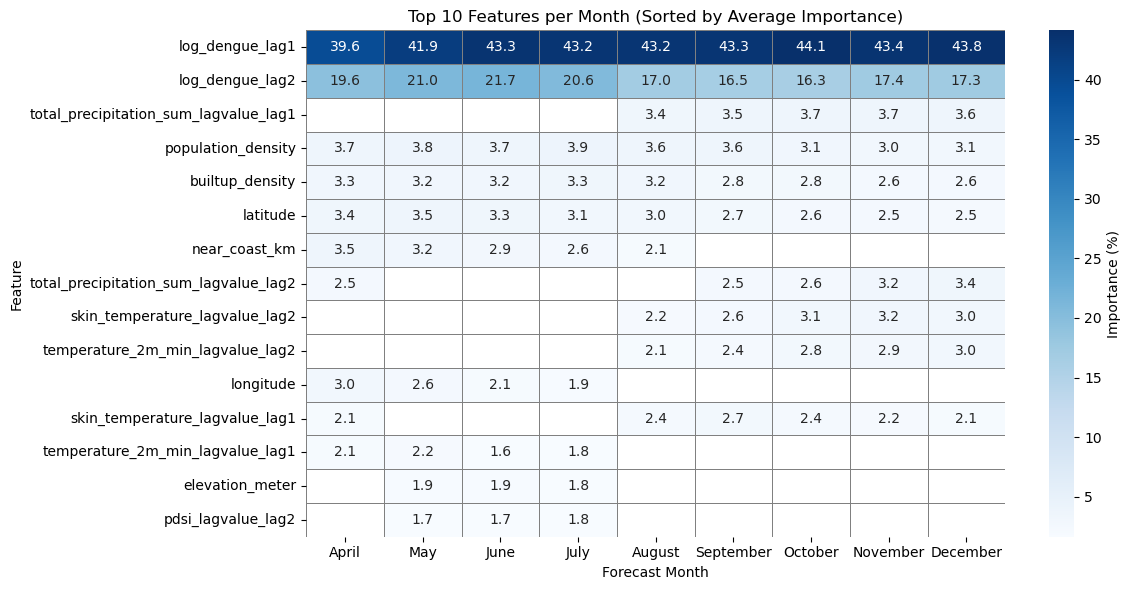

In [9]:
## Feature Importance Heatmap

# Build union of top 10 features per month
top_features_set = set()
for month, fi in feature_importances.items():
    top10 = fi.sort_values('importance', ascending=False).head(10)['feature']
    top_features_set.update(top10)

# Convert set to list
top_features_list = list(top_features_set)

# reate DataFrame: rows = features, columns = months
months = list(feature_importances.keys())
heatmap_df = pd.DataFrame(index=top_features_list, columns=months)

# Fill in only the top 10 features for each month
for month in months:
    fi = feature_importances[month].set_index('feature')['importance']
    top10_features = fi.sort_values(ascending=False).head(10).index
    for feature in top_features_list:
        heatmap_df.at[feature, month] = fi.get(feature) if feature in top10_features else np.nan

# Convert to percentages
heatmap_df = 100 * heatmap_df.astype(float)

# Remove features that are NaN for all months
heatmap_df = heatmap_df.dropna(how='all')

# Sort features by average importance across months (highest first)
heatmap_df['avg_importance'] = heatmap_df.mean(axis=1, skipna=True)
heatmap_df = heatmap_df.sort_values('avg_importance', ascending=False)
heatmap_df = heatmap_df.drop(columns='avg_importance')

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="Blues",
            cbar_kws={'label': 'Importance (%)'},
            linewidths=0.5, linecolor='gray')

plt.xlabel("Forecast Month")
plt.ylabel("Feature")
plt.title("Top 10 Features per Month (Sorted by Average Importance)")
plt.tight_layout()
plt.show()


In [26]:
## Hot Spot Network Analysis

# Load Dengue Data

file_path = "/home/amolla/GIS_Spring26/GIS_521_FinalProject/brazil_dengue_HotSpot95Confd.csv"
df = pd.read_csv(file_path)

lat_col = "latitude"
lon_col = "longitude"

monthly_cols = [
    "den_2019_01","den_2019_02","den_2019_03","den_2019_04",
    "den_2019_05","den_2019_06","den_2019_07","den_2019_08",
    "den_2019_09","den_2019_10","den_2019_11","den_2019_12"
]

df[monthly_cols] = df[monthly_cols].fillna(0)
df["den_2019_total"] = df[monthly_cols].sum(axis=1)
weights = df["den_2019_total"].values


# Weighted Gravitational Centroid

centroid_lat = np.sum(df[lat_col] * weights) / np.sum(weights)
centroid_lon = np.sum(df[lon_col] * weights) / np.sum(weights)

print("Weighted Gravitational Centroid (2019 dengue):")
print("Latitude:", centroid_lat)
print("Longitude:", centroid_lon)


# Haversine Distance Function

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1)*cos(phi2)*sin(dlambda/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c


# Build 500 km Network

threshold_km = 500
G = nx.Graph()
n = len(df)

for i in range(n):
    G.add_node(i)

for i in range(n):
    for j in range(i+1, n):
        dist_ij = haversine(df.loc[i, lat_col], df.loc[i, lon_col],
                            df.loc[j, lat_col], df.loc[j, lon_col])
        if dist_ij <= threshold_km:
            G.add_edge(i, j)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges (≤500 km):", G.number_of_edges())


# Create Base Map

m = folium.Map(
    location=[df[lat_col].mean(), df[lon_col].mean()],
    zoom_start=5,
    tiles="CartoDB Positron"
)


# Draw Network Edges

edge_layer = folium.FeatureGroup(name="500km Network")

for edge in G.edges():
    lat1 = df.loc[edge[0], lat_col]
    lon1 = df.loc[edge[0], lon_col]
    lat2 = df.loc[edge[1], lat_col]
    lon2 = df.loc[edge[1], lon_col]

    folium.PolyLine(
        locations=[(lat1, lon1), (lat2, lon2)],
        weight=1,
        color="blue",
        opacity=0.5
    ).add_to(edge_layer)

edge_layer.add_to(m)


# Draw Municipality Nodes

node_layer = folium.FeatureGroup(name="Municipalities")

max_weight = df["den_2019_total"].max()

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row[lat_col], row[lon_col]],
        radius=3 + (row["den_2019_total"] / max_weight) * 8,
        fill=False,
        color="red",
        weight=2,
        popup=f"Total 2019 Dengue: {row['den_2019_total']}"
    ).add_to(node_layer)

node_layer.add_to(m)


# Add Gravitational Centroid

centroid_layer = folium.FeatureGroup(name="Gravitational Centroid")

folium.Marker(
    location=[centroid_lat, centroid_lon],
    popup="Weighted Gravitational Centroid (2019)",
    icon=folium.Icon(color="green", icon="star")
).add_to(centroid_layer)

centroid_layer.add_to(m)


# Load and Add Airports

airport_csv = "/home/amolla/GIS_Spring26/GIS_521_FinalProject/Brazil_Airport.csv"
airport_df = pd.read_csv(airport_csv, encoding="latin1")

airport_df["Location"] = airport_df["Location"].str.strip()
airport_df[["lat", "lon"]] = airport_df["Location"].str.split(",", expand=True)

airport_df["lat"] = airport_df["lat"].astype(float)
airport_df["lon"] = airport_df["lon"].astype(float)

airport_layer = folium.FeatureGroup(name="Airports")

for _, row in airport_df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,
        color="black",
        fill=True,
        fill_color="yellow",
        fill_opacity=0.9,
        popup=f"Airport: {row['Airport']}"
    ).add_to(airport_layer)

airport_layer.add_to(m)


# Add Layer Control

folium.LayerControl(collapsed=False).add_to(m)


# Save Map

output_path = "/home/amolla/GIS_Spring26/GIS_521_FinalProject/brazil_weighted_network_500km_with_airports.html"
m.save(output_path)

print("Map saved to:", output_path)


Weighted Gravitational Centroid (2019 dengue):
Latitude: -17.968080988133536
Longitude: -45.038928795916725
Number of nodes: 23
Number of edges (≤500 km): 75
Map saved to: /home/amolla/GIS_Spring26/GIS_521_FinalProject/brazil_weighted_network_500km_with_airports.html


Data shape: (55680, 69)

=== Correlation of Predictors with Target ===
log_dengue                               1.000000
log_dengue_lag1                          0.757233
log_dengue_lag2                          0.496987
temperature_2m_min_lagvalue_lag2         0.200248
builtup_density                          0.189165
population_density                       0.175287
total_precipitation_sum_lagvalue_lag2    0.154619
skin_temperature_lagvalue_lag2           0.148113
temperature_2m_min_lagvalue_lag1         0.127389
total_precipitation_sum_lagvalue_lag1    0.122141
temperature_2m_max_lagvalue_lag2         0.090272
skin_temperature_lagvalue_lag1           0.053009
near_coast_km                            0.035279
longitude                                0.031352
elevation_meter                          0.013718
latitude                                -0.005305
pdsi_lagvalue_lag1                      -0.019668
temperature_2m_max_lagvalue_lag1        -0.047259
pdsi_lagvalue_lag2           

/tmp/ipykernel_3829585/1018917112.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


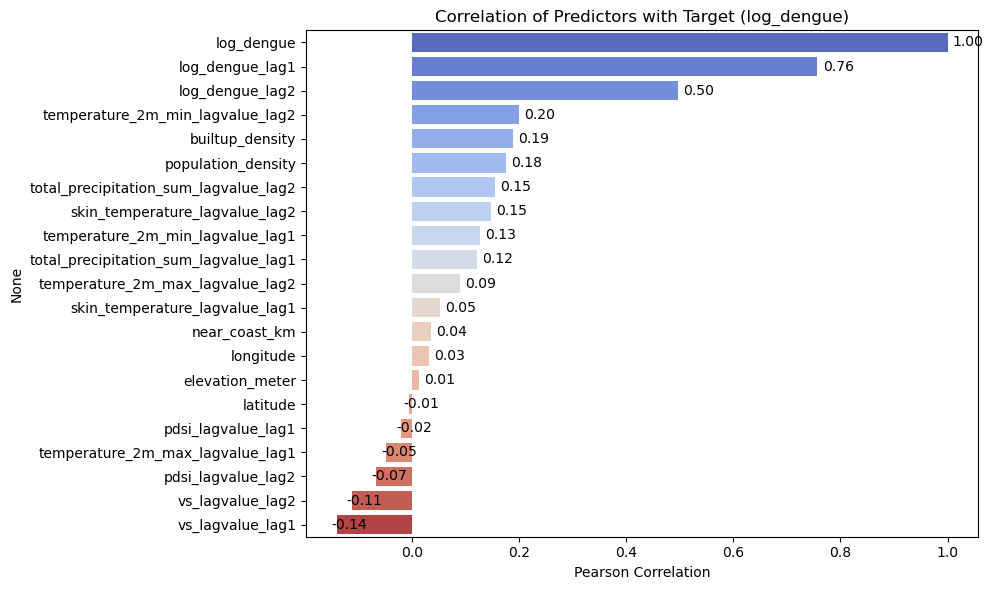

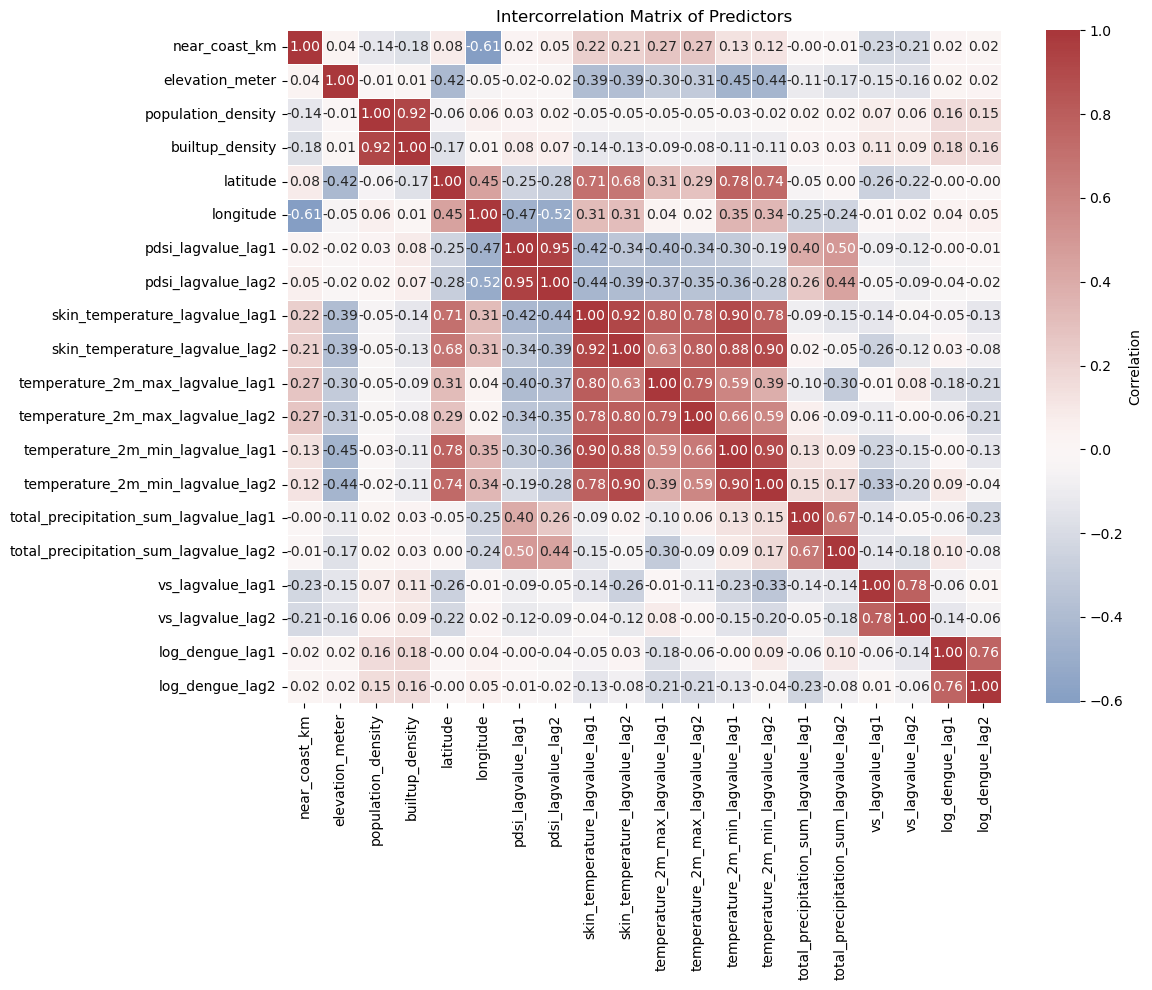

In [7]:
# Correlation Analysis with Values Shown

# Load dataset

csv_path = "/home/amolla/GIS_Spring26/GIS_521_FinalProject/brazil_panel_2019_FINAL.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()
df["date"] = pd.to_datetime(df["date"])

print("Data shape:", df.shape)


# Create log-transformed dengue & lag variables

if "dengue" not in df.columns:
    raise ValueError("Your CSV must contain a 'dengue' column")

df["log_dengue"] = np.log1p(df["dengue"])

if "Common_ID" not in df.columns:
    df["Common_ID"] = df.index  # fallback if no municipality ID

df = df.sort_values(["Common_ID", "date"])

df["log_dengue_lag1"] = df.groupby("Common_ID")["log_dengue"].shift(1)
df["log_dengue_lag2"] = df.groupby("Common_ID")["log_dengue"].shift(2)
df[["log_dengue_lag1", "log_dengue_lag2"]] = df[["log_dengue_lag1", "log_dengue_lag2"]].fillna(0)


# Define features

target = "log_dengue"

static_vars = [
    "near_coast_km", "elevation_meter",
    "population_density", "builtup_density",
    "latitude", "longitude"
]

monthly_vars = [
    "pdsi",
    "skin_temperature",
    "temperature_2m_max", "temperature_2m_min",
    "total_precipitation_sum", "vs"
]

climate_lags = [
    f"{var}_lagvalue_lag{lag}"
    for var in monthly_vars
    for lag in range(1,3)
]

lagged_dengue = ["log_dengue_lag1", "log_dengue_lag2"]

features = static_vars + climate_lags + lagged_dengue


# Correlation of predictors with target

corr_with_target = df[features + [target]].corr()[target].sort_values(ascending=False)

print("\n=== Correlation of Predictors with Target ===")
print(corr_with_target)

# Plot predictor-target correlations with exact values
plt.figure(figsize=(10,6))
bars = sns.barplot(
    x=corr_with_target.values,
    y=corr_with_target.index,
    palette="coolwarm"
)

# Add correlation values to bars
for bar in bars.patches:
    width = bar.get_width()
    plt.text(width + 0.01*np.sign(width), bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center', fontsize=10)

plt.title("Correlation of Predictors with Target (log_dengue)")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()



# Intercorrelation among predictors

predictor_corr = df[features].corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    predictor_corr, 
    cmap="vlag", 
    center=0, 
    annot=True,       # show values
    fmt=".2f",        # two decimal places
    cbar_kws={'label': 'Correlation'},
    linewidths=0.5
)
plt.title("Intercorrelation Matrix of Predictors")
plt.tight_layout()
plt.show()